In [180]:
from sklearn.datasets import make_classification
import numpy as np

In [181]:
X,y = make_classification(n_samples=100,n_features=2,n_classes=2,n_clusters_per_class=1,class_sep=20,
                          n_informative=1,hypercube=False, random_state=41,n_redundant=0)

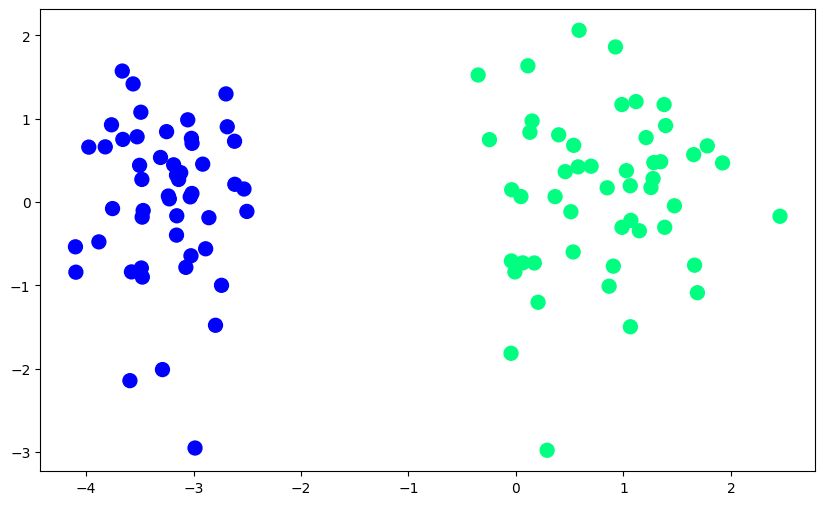

In [182]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [183]:
print(X.shape)
print("*************")
print(y.shape)

(100, 2)
*************
(100,)


## Applying SKlearn Logistic Regression

In [184]:
from sklearn.linear_model import LogisticRegression

In [185]:
lr = LogisticRegression(solver="sag",penalty=None)

In [186]:
lr.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [187]:
print(lr.coef_)
print(lr.intercept_)

[[4.80486701 0.21747652]]
[5.77192761]


In [188]:
m1 = -(lr.coef_[0][0]/lr.coef_[0][1])
b1 = -(lr.intercept_/lr.coef_[0][1])

In [189]:
x_input = np.linspace(-3,3,100)
y_input = m1* x_input + b1

## Creating Gradient based Logistic Regression Function

In [190]:
def gd(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

    return weights[1:],weights[0]


In [191]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [192]:
coef_,intercept_=gd(X,y)

In [193]:
coef_

array([4.83926872, 0.21182255])

In [194]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [195]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

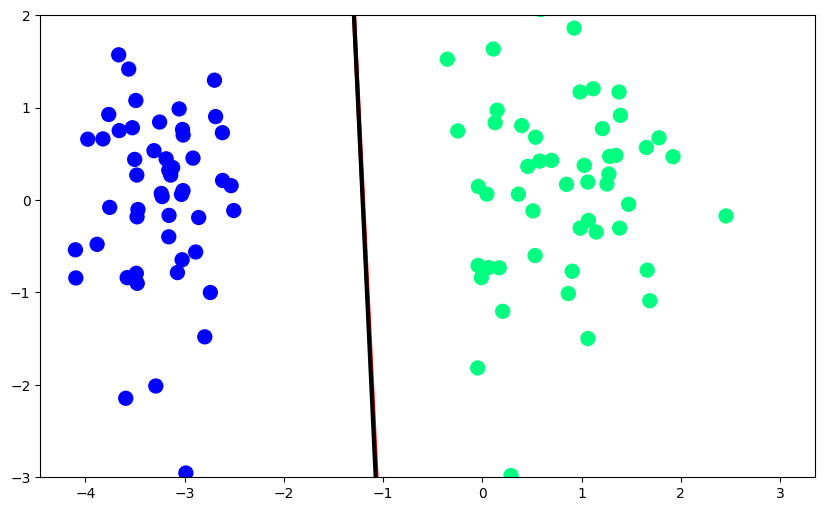

In [196]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)